# DrivePrice AI: Predicting the Road Ahead

## Imports and Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
# Ensure 'car_price_dataset.csv' is in the same directory as your notebook
df = pd.read_csv('/kaggle/input/datasets/upcoderr/car-specifications-dataset/car_price_dataset.csv')

# Initial inspection
print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (2000, 11)


,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB
None


## Exploratory Data Analysis (EDA)

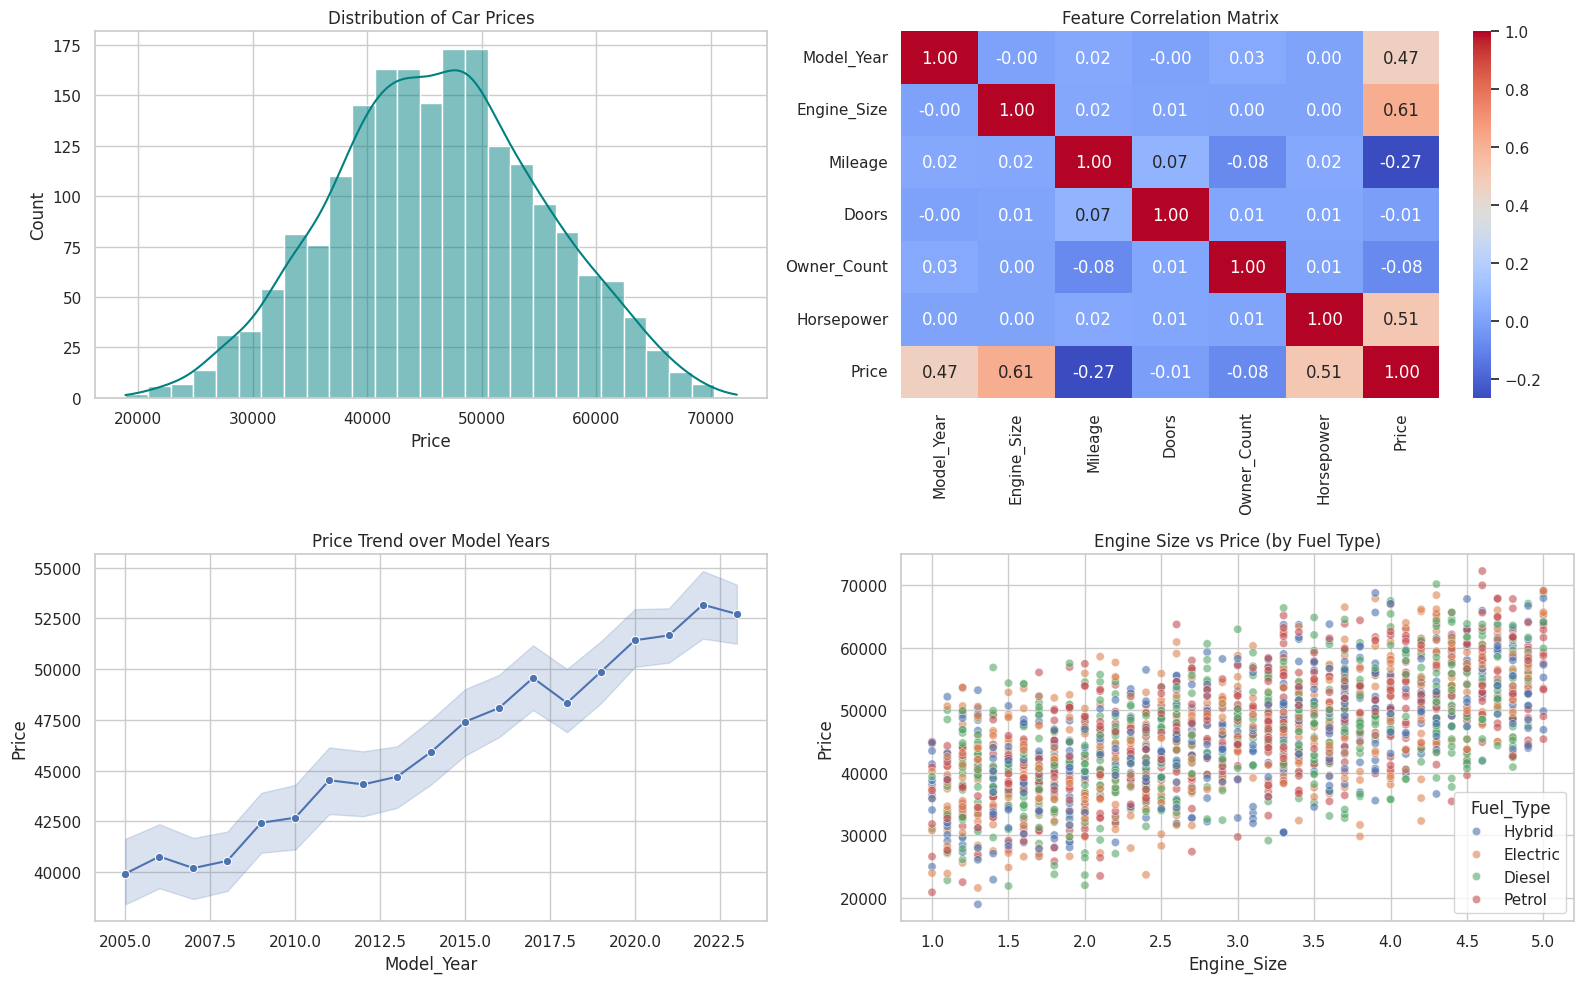

In [2]:
plt.figure(figsize=(16, 10))

# 1. Price Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Price'], kde=True, color='teal')
plt.title('Distribution of Car Prices')

# 2. Correlation Heatmap (Numerical columns)
plt.subplot(2, 2, 2)
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Car_ID'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')

# 3. Model Year vs Price (Depreciation Trend)
plt.subplot(2, 2, 3)
sns.lineplot(x='Model_Year', y='Price', data=df, marker='o')
plt.title('Price Trend over Model Years')

# 4. Engine Size vs Price
plt.subplot(2, 2, 4)
sns.scatterplot(x='Engine_Size', y='Price', hue='Fuel_Type', data=df, alpha=0.6)
plt.title('Engine Size vs Price (by Fuel Type)')

plt.tight_layout()
plt.show()

## Data Preprocessing

In [3]:
# 1. Drop identifier column
df_ml = df.drop(columns=['Car_ID'])

# 2. Handle Categorical variables using One-Hot Encoding
df_ml = pd.get_dummies(df_ml, columns=['Brand', 'Fuel_Type', 'Transmission'], drop_first=True)

# 3. Separate features (X) and target (y)
X = df_ml.drop(columns=['Price'])
y = df_ml['Price']

# 4. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scaling
# We use a scaler for Linear Regression and Neural Networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessed Features: {X.shape[1]}")

Preprocessed Features: 15


## Model Training and Evaluation

In [4]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)
}

results = {}

# Training loop
for name, model in models.items():
    # Use scaled data for LR and MLP
    if name in ['Linear Regression', 'Neural Network']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Tree-based models can handle raw data
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

# Display results as a DataFrame
results_df = pd.DataFrame(results).T
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


,RMSE,R2
Linear Regression,1663.28,0.9665
Random Forest,2608.87,0.9175
Gradient Boosting,1924.81,0.9551
Neural Network,1927.84,0.9550


## Feature Importance and Interpretability

/tmp/ipykernel_18/2406200388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


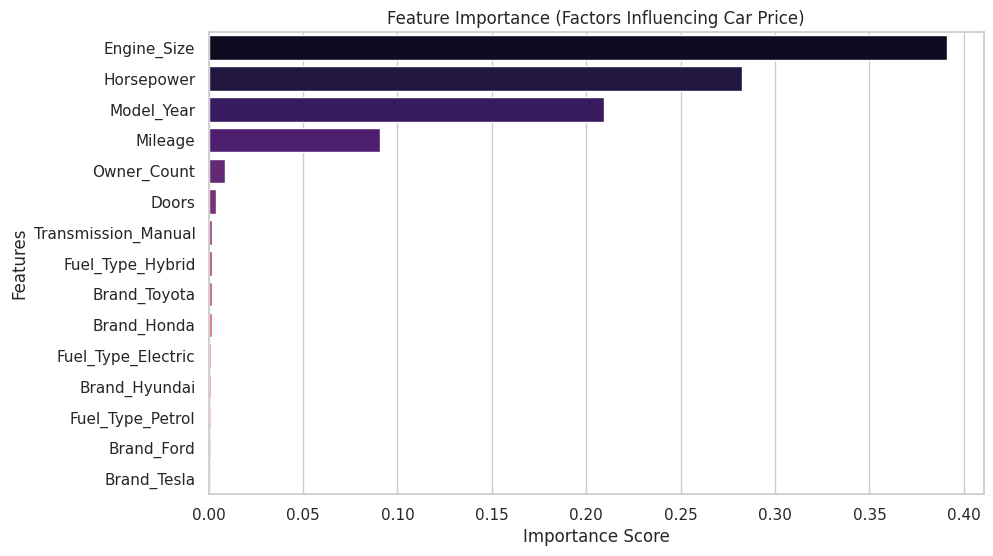

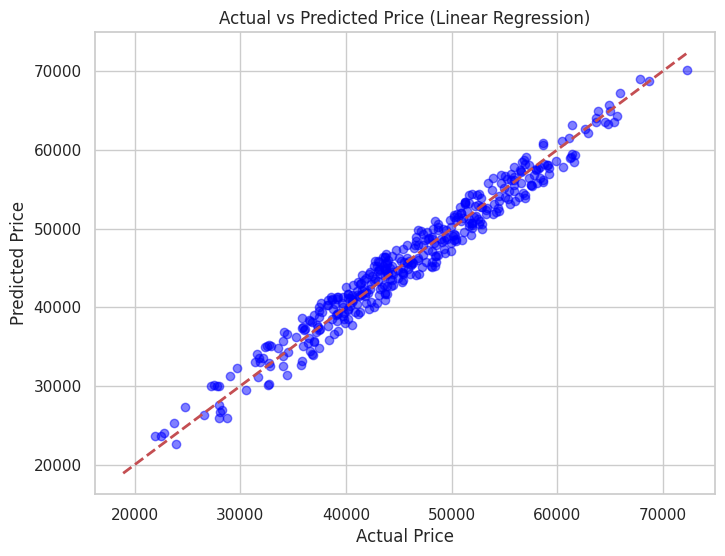

In [5]:
# Extracting importance from Random Forest
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Feature Importance (Factors Influencing Car Price)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Verification of Prediction Accuracy
best_model = models['Linear Regression']
y_pred_final = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Linear Regression)')
plt.show()